# Taller Práctico: Clasificación de Riesgo Crediticio con Perceptrón
## Contexto del Problema
Una entidad financiera desea automatizar la aprobación de créditos pre-aprobados.

Se cuenta con dos variables de entrada:

* Puntaje Crediticio (Normalizado de 0 a 1).

* Ratio de Ahorro (Dinero ahorrado vs ingresos anuales).

El objetivo es entrenar un Perceptrón Simple en Keras para que aprenda la frontera de decisión que separa a los clientes de "Bajo Riesgo" (Clase 1) de los de "Alto Riesgo" (Clase 0).

## Paso 1: Preparación del Entorno
Cargamos las librerías necesarias y generamos un dataset sintético que represente este escenario.

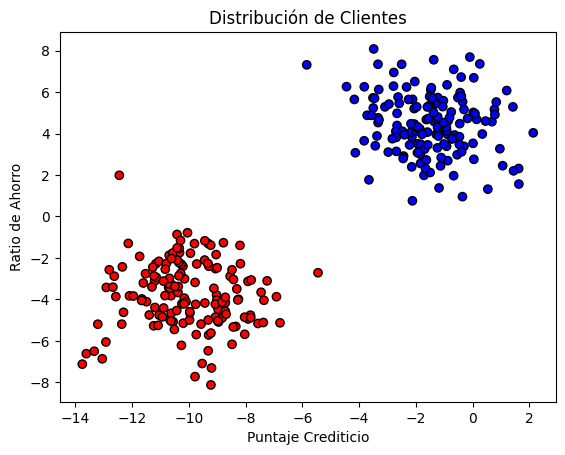

In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_blobs

# Generamos datos: 300 clientes con 2 características
X, y = make_blobs(n_samples=300, centers=2, n_features=2, cluster_std=1.5, random_state=1)

# Visualización inicial
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.xlabel("Puntaje Crediticio")
plt.ylabel("Ratio de Ahorro")
plt.title("Distribución de Clientes")
plt.show()

## Paso 2: Definición de la Arquitectura (Misión del Alumno)
Debes definir un modelo secuencial que represente un Perceptrón Simple. Recuerda que para una clasificación binaria, la salida debe pasar por una función que comprima el valor entre 0 y 1.

**Guía Técnica:**

* Usa una capa Dense.

* Como es un Perceptrón de una sola capa, units debe ser igual a 1.

* El input_shape debe coincidir con la cantidad de variables de entrada (2).

In [ ]:
# --- COMPLETA EL CÓDIGO AQUÍ ---
model = Sequential([
    # Define la capa Dense con 1 neurona y activación 'sigmoid'

])
# ------------------------------

## Paso 3: Compilación del Sistema
Para que el modelo aprenda, debemos definir el Optimizador (que gestiona la Tasa de Aprendizaje) y la Función de Pérdida (que mide el error).

**Ayuda Sugerida:**

* Para clasificación binaria, la pérdida estándar es binary_crossentropy.

* Experimenta con diferentes valores en learning_rate (prueba con 0.01, 0.1 y 0.5).

In [ ]:
# --- COMPLETA EL CÓDIGO AQUÍ ---
# Usa model.compile(...)
# Define el optimizer usando tf.keras.optimizers.SGD y la loss adecuada.

# ------------------------------

## Paso 4: Entrenamiento y Regularización
Es momento de ajustar los pesos. Vamos a entrenar el modelo, pero esta vez, presta atención a cómo el número de épocas afecta el resultado.

**Instrucciones:**

* Ejecuta el método .fit().

* Prueba configurar el entrenamiento con 50 épocas.

In [ ]:
# --- COMPLETA EL CÓDIGO AQUÍ ---
# history = model.fit(..., epochs=..., verbose=1)

# ------------------------------

## Paso 5: Evaluación de Resultados
Una vez entrenado, utilizaremos el siguiente bloque para visualizar la Frontera de Decisión que tu modelo ha construido.

In [ ]:
def plot_frontier(X, y, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='bwr')
    plt.show()

plot_frontier(X, y, model)

## Desafíos Extra
**Impacto del Sesgo:** Si imprimes los pesos del modelo con model.get_weights(), ¿cuál es el valor del Bias?

¿Qué pasaría si fuera cero?

**Regularización:** Regresa al Paso 2 e intenta agregar kernel_regularizer='l2' dentro de la capa Dense.

¿Notas algún cambio en la suavidad de la frontera o en el valor de los pesos?

**No Linealidad:** Cambia el generador de datos por make_moons(n_samples=300, noise=0.1).

¿Es capaz el Perceptrón de una sola capa de separar estos datos? Justifica basándote en la teoría de Separabilidad Lineal.